<a href="https://colab.research.google.com/github/anjaperovic/credit-card-fraud/blob/main/Projekat.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Primena neuronskih mreža za predviđanje prevara u finansijama (credit card fraud detection)**

# **Potrebni importi**

In [ ]:
# Osnovne biblioteke
import numpy as np
import pandas as pd
import random
import os

# Vizuelizacija
import matplotlib.pyplot as plt
import seaborn as sns

# PyTorch bioblioteke za duboko učenje
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Scikit-Learn za preprocesiranje i evaluaciju
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.metrics import precision_score, recall_score, f1_score

**Fiksiranje semena (seed) radi osiguravanja reproduktivnosti i identičnih rezultata pri svakom pokretanju koda**

Konfigurisan je fiksni random seed (seme slučajnosti). S obzirom na to da obučavanje neuronskih mreža prirodno sa sobom nosi nasumičnost — pre svega kroz inicijalne težine neurona i mešanje uzoraka — ovaj korak je neophodan kako bi se kôd ponašao identično pri svakom pokretanju. Fiksiranjem ovog parametra postižemo punu ponovljivost eksperimenta. Time je osigurano da svako naredno pomeranje loss-a ili skok u preciznosti modela bude isključivo posledica naših izmena u arhitekturi slojeva i hiperparametrima, a ne puke sreće sa nasumičnim brojevima.

In [ ]:
RAND_STATE = 42

def set_seed(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(RAND_STATE)

**Učitavanje podataka**

In [ ]:
from google.colab import files
data_file = files.upload()


Saving creditcard.csv to creditcard.csv


In [ ]:
import io
df = pd.read_csv(io.BytesIO(data_file['creditcard.csv']))


In [ ]:
print("Prvih 5 redova u skupu podataka: \n")
df.head()

Prvih 5 redova u skupu podataka: 



,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
print("Osnovne informacije o skupu podataka: \n")
df.info()

Osnovne informacije o skupu podataka: 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     

Analizom skupa podataka možemo vidimo da imamo 284 807 transakcija. Skup podataka sadrži 30 numeričkih kolona. Atribut Time predstavlja broj sekundi proteklih od prve transakcije. Atribut Amount predstavlja iznos transakcije. Atributi V1–V28 predstavljaju numeričke karakteristike transakcija koje su dobijene primenom PCA (Principal Component Analysis) transformacije nad originalnim podacima. Ciljni atribut Class je binarne prirode i označava da li je transakcija regularna (0) ili je prevara (1).

**Distribucija klasa**

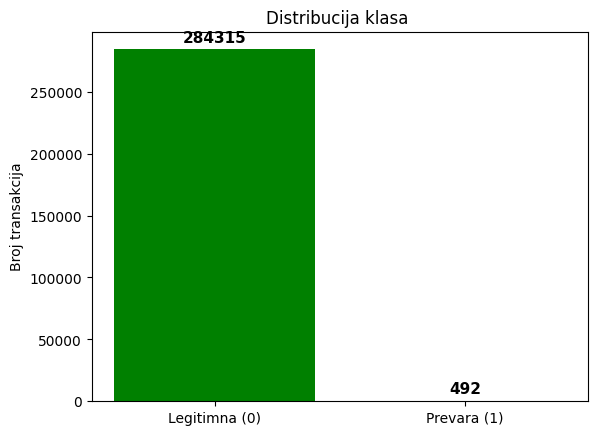

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


In [ ]:
counts = df['Class'].value_counts()
bars = plt.bar(['Legitimna (0)', 'Prevara (1)'], counts.values, color=['green','red'])
plt.bar_label(bars, padding=3, fontsize=11, weight='bold')

plt.title('Distribucija klasa ')
plt.ylabel('Broj transakcija')
plt.show()

print(df['Class'].value_counts(normalize=True) * 100)


Distribucijom klasa primećujemo da prevare čine izuzetno mali deo transakcija, čak manje od 0.5%.

# **Podela na train i test**

In [ ]:
# Definisanje ulaznih obeležja
X = df.drop(columns=['Class'])

# Definisanje ciljne promenljive
y = df['Class']

In [ ]:
# Stratifikovana podela 80% / 20%
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RAND_STATE, stratify=y
)

# **Skaliranje podataka**

In [ ]:
scaler = StandardScaler()
kolone_za_skaliranje = ['Time', 'Amount']

X_train_scaled = X_train.copy()
X_train_scaled[kolone_za_skaliranje] = scaler.fit_transform(X_train[kolone_za_skaliranje])

X_test_scaled = X_test.copy()
X_test_scaled[kolone_za_skaliranje] = scaler.transform(X_test[kolone_za_skaliranje])

Standardizacijom kolona 'Time' i 'Amount' dovodimo sve ulazne podatke u isti numerički opseg, pri čemu parametre skaliranja računamo isključivo na trening skupu kako bismo sprečili curenje podataka u test skup.

# **Model 1: Baseline model (Scikit-Learn MLPClassifier)**

Kao polazna tačka istraživanja kreiran je bazni (Baseline) model zasnovan na Scikit-Learn MLPClassifier neuronskoj mreži, sa ciljem da se utvrde performanse klasifikacije na sirovim, nebalansiranim podacima i postavi osnova za dalju evaluaciju naprednijih modela.

**Treniranje modela**

In [ ]:
model_1_sklearn_mlp = MLPClassifier(
    hidden_layer_sizes=(64, 16),
    max_iter=1000,
    random_state=RAND_STATE
)

model_1_sklearn_mlp.fit(X_train_scaled, y_train)

MLPClassifier(hidden_layer_sizes=(64, 16), max_iter=1000, random_state=42)

In [ ]:
print("Broj ulaznih neurona:", X_train.shape[1])
print("Skriveni slojevi:", model_1_sklearn_mlp.hidden_layer_sizes)

Broj ulaznih neurona: 30
Skriveni slojevi: (64, 16)


Model se sastoji od ulaznog sloja sa 30 neurona, dva skrivena sloja i jednog izlaznog neurona koji daje konačnu predikciju (0 ili 1). Prvi skriveni sloj sadrži 64 neurona, dok je broj neurona u drugom sloju redukovan na 16. Ova struktura (arhitektura levka) primorava mrežu da kompresuje informacije, čime se filtrira šum i zadržavaju samo najvažniji obrasci koji razlikuju legitimne transakcije od prevara, što ujedno smanjuje i rizik od overfitting-a.

**Kriva gubitka**

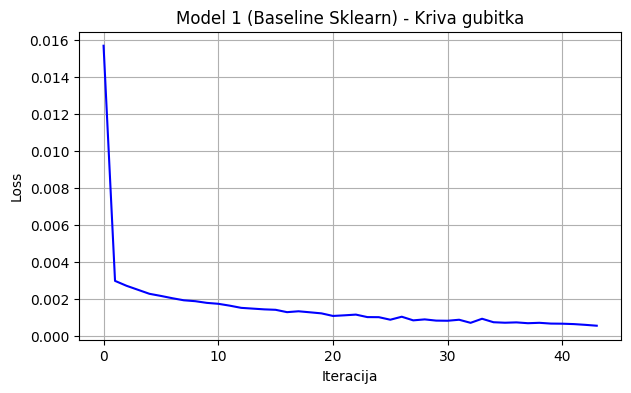

In [ ]:
plt.figure(figsize=(7,4))
plt.plot(model_1_sklearn_mlp.loss_curve_, color='blue')
plt.xlabel("Iteracija")
plt.ylabel("Loss")
plt.title("Model 1 (Baseline Sklearn) - Kriva gubitka")
plt.grid(True)
plt.show()

Fokusirali smo se na krivu gubitka jer ona predstavlja grafički prikaz vrednosti funkcije greške kroz epohe, što nam omogućava vizuelno praćenje konvergencije modela i kontrolu preprilagođavanja.

Sa grafikona se uočava drastičan pad vrednosti funkcije greške već u prvoj iteraciji (sa 0.016 na manje od 0.003). Ovo je karakteristično za skupove podataka sa visokim stepenom klasnog debalansa. Mreža u prvom koraku 'shvata' da statističku grešku najbrže smanjuje tako što većinu transakcija klasifikuje kao legitimne, čime instantno minimizuje ukupni gubitak. Nakon toga, kriva poprima stabilan, opadajući trend bez izraženih oscilacija. Iako je parametar *max_iter* bio konfigurisan na 1000, algoritam je prekinuo obučavanje već nakon 44. iteracije jer dalji rad nije donosio značajno smanjenje greške.

In [ ]:
print("Broj izlaznih neurona:", model_1_sklearn_mlp.n_outputs_)

for i, coef in enumerate(model_1_sklearn_mlp.coefs_):
    print(f"Matrica težina {i+1}: {coef.shape}")

for i, bias in enumerate(model_1_sklearn_mlp.intercepts_):
    print(f"Bias vektor {i+1}: {bias.shape}")

print("\nBroj iteracija:", model_1_sklearn_mlp.n_iter_)
print("Finalni loss:", model_1_sklearn_mlp.loss_)

Broj izlaznih neurona: 1
Matrica težina 1: (30, 64)
Matrica težina 2: (64, 16)
Matrica težina 3: (16, 1)
Bias vektor 1: (64,)
Bias vektor 2: (16,)
Bias vektor 3: (1,)

Broj iteracija: 44
Finalni loss: 0.0005742309705249101


Uvidom u unutrašnju strukturu obučenog modela, možemo precizno pratiti transformaciju dimenzija podataka kroz slojeve. Izlaz potvrđuje uspešnu implementaciju projektovane arhitekture levka. Prva matrica težina transformiše 30 ulaznih neuronskih signala u 64 zapisa prvog skrivenog sloja. Ključni korak kompresije informacija vidi se u drugoj matrici težina dimenzija (64, 16), koja redukuje prostor obeležja na 16 neurona, pre nego što finalna matrica mapira te podatke u jedan izlazni neuron za binarnu klasifikaciju.

Proces obučavanja je automatski zaustavljen nakon 44 iteracije aktivacijom pravila ranog zaustavljanja (early stopping). Iako je postignut izuzetno nizak finalni gubitak od 0.00057, ova vrednost se mora interpretirati sa oprezom. Zbog ekstremnog klasnog debalansa u korist legitimnih transakcija, niska vrednost funkcije greške je primarno odraz visoke tačnosti nad većinskom klasom, dok se stvarna sposobnost prepoznavanja prevara mora detaljnije evaluirati kroz specifične matrične metrike.

**Evaluacija modela**

In [ ]:
y_pred_1 = model_1_sklearn_mlp.predict(X_test_scaled)
print("\nKlasifikacioni izveštaj za Model 1:")
print(classification_report(y_test, y_pred_1, target_names=['Legitimna (0)', 'Prevara (1)']))


Klasifikacioni izveštaj za Model 1:
               precision    recall  f1-score   support

Legitimna (0)       1.00      1.00      1.00     56864
  Prevara (1)       0.85      0.81      0.83        98

     accuracy                           1.00     56962
    macro avg       0.92      0.90      0.91     56962
 weighted avg       1.00      1.00      1.00     56962



Nakon završenog procesa obučavanja, performanse Baseline MLP modela evaluirane su na testnom skupu podataka. Rezultati klasifikacionog izveštaja pokazuju visoku efikasnost modela, čak i pre primene naprednih metoda za balansiranje klasa.

Vrednost ukupne tačnosti (**Accuracy**) iznosi 1.00 (100%), što u kontekstu ekstremnog klasnog debalansa predstavlja varku i neadekvatnu metriku.

Za većinsku klasu (legitimne transakcije), model ostvaruje maksimalne vrednosti svih metrika (1.00), što je očekivano s obzirom na visoku zastupljenost ove klase u testnom uzorku (56.864 instanci). Ključni indikator kvaliteta modela jesu performanse nad manjinskom klasom (prevare), gde je identifikovano ukupno 98 instanci. Model postiže preciznost (**Precision**) od 0.85, što znači da je 85% transakcija koje je model označio kao prevare zaista bilo kompromitovano. Odziv (**Recall**) iznosi 0.81, što dokumentuje da je model uspešno detektovao 81% stvarnih prevara na testu, dok je **F1-vrednost** od 0.83 potvrdila stabilan balans između ove dve metrike.



**Matrica konfuzije**

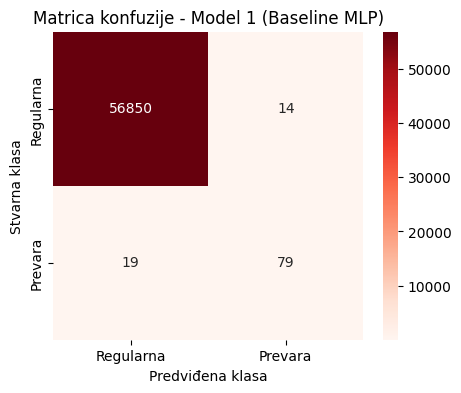

In [ ]:
cm_1 = confusion_matrix(y_test, y_pred_1)
plt.figure(figsize=(5,4))
sns.heatmap(cm_1, annot=True, fmt='g', cmap='Reds',
            xticklabels=['Regularna', 'Prevara'], yticklabels=['Regularna', 'Prevara'])
plt.title("Matrica konfuzije - Model 1 (Baseline MLP)")
plt.ylabel('Stvarna klasa')
plt.xlabel('Predviđena klasa')
plt.show()

Za detaljniji uvid u distribuciju tačnih i pogrešnih predikcija Baseline MLP modela generisana je matrica konfuzije prikazana na grafikonu. Unutar matrice jasno se mogu identifikovati apsolutne vrednosti za četiri ključna segmenta evaluacije.

Model je uspešno klasifikovao 56.850 legitimnih transakcija kao regularne (**True Negative**), dok je od ukupno 98 stvarnih prevara uspešno detektovao **79** instanci (**True Positive**).

U svega **14** slučajeva model je regularnu transakciju pogrešno označio kao sumnjivu (**False Positive**). Sa poslovnog aspekta, ovako nizak broj lažnih uzbuna je izuzetno povoljan jer minimizuje nepotrebno blokiranje korisničkih računa i održava visok nivo zadovoljstva klijenata. Model je propustio ukupno 19 stvarnih finansijskih prevara, klasifikujući ih kao regularne transakcije (**False Negative**). U realnim sistemima za detekciju prevara, upravo ovaj tip greške predstavlja najveću opasnost jer direktno generiše finansijski gubitak za banku i klijente.

# **Uvod u  PyTorch**

Dok nam je Scikit-Learn odlično poslužio za brzi Baseline model, on nas prilično ograničava jer radi kao "crna kutija" i oslanja se na standardne NumPy nizove. Za ozbiljnije neuronske mreže potreban nam je PyTorch. Prelaskom na ovo okruženje počinjemo da radimo sa tenzorima – strukturama koje možemo direktno da prebacimo na grafičku karticu (GPU). Pošto naš dataset ima ogroman broj transakcija, ovo hardversko ubrzanje je ključno da ne bismo satima čekali da se mreža obuči.

Druga velika prednost je PyTorch-ov ugrađeni autograd sistem. On samostalno prati sve matematičke operacije i automatski odrađuje propagaciju greške unazad (backpropagation), što nas oslobađa ručnog računanja komplikovanih izvoda. Na kraju, kôd u PyTorch-u nam daje potpunu inženjersku slobodu da model sklapamo bukvalno sloj po sloj i precizno kontrolišemo kako mreža uči.

**Pretvaranje u tenzore**

Pre kreiranja same arhitekture neuronske mreže, podatke je potrebno transformisati iz tabelarnog formata u strukture optimizovane za rad u PyTorch okruženju. Ovaj korak se izvodi kroz nekoliko faza:

* **Konverzija u tenzore:** Atributi i labele se prevode u `torch.tensor` format uz definisanje standardne `float32` preciznosti.
* **Sjedinjavanje setova podataka:** Korišćenjem klase `TensorDataset`, ulazni podaci i njihove pripadajuće labele se spajaju u jedinstvene celine, čime se garantuje konzistentnost i onemogućava razdvajanje transakcija od njihovih stvarnih oznaka tokom treninga.
* **Konfiguracija mini-grupa (DataLoader):** Zbog veličine samog skupa podataka, proces obučavanja se izvodi u paketima. Veličina mini-grupe je postavljena na **2048 uzoraka** (`BATCH_SIZE = 2048`), što omogućava stabilniji gradijent i efikasnije korišćenje računarskih resursa pri obradi velikog broja transakcija.
    * Za potrebe treninga aktivirano je nasumično mešanje uzoraka (`shuffle=True`) kako bi se izbeglo memorisanje hronološkog redosleda instanci.
    * Kod testnog skupa mešanje je isključeno (`shuffle=False`) radi očuvanja fiksnog redosleda koji je neophodan za kasniju tačnu evaluaciju performansi i generisanje matrice konfuzije.


In [ ]:
X_train_t = torch.tensor(X_train_scaled.values, dtype=torch.float32)
X_test_t = torch.tensor(X_test_scaled.values, dtype=torch.float32)
y_train_t = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1)
y_test_t = torch.tensor(y_test.values, dtype=torch.float32).unsqueeze(1)

train_dataset = TensorDataset(X_train_t, y_train_t)
test_dataset = TensorDataset(X_test_t, y_test_t)

In [ ]:
BATCH_SIZE = 2048
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# **Model 2: Osnovni PyTorch Model**



U ovom koraku definišemo strukturu našeg drugog modela — potpuno povezane veštačke neuronske mreže (Multilayer Perceptron - MLP). Mreža je implementirana kroz klasu `FraudDetectionMLP` koja nasleđuje bazični PyTorch modul `nn.Module`.

Arhitektura prati jasan šablon postepenog sažimanja informacija kroz strukturu slojeva $30 \rightarrow 64 \rightarrow 16 \rightarrow 1$:

* **Ulazna dimenzija (30):** Prvi sloj (`fc1`) striktno prihvata 30 ulaznih karakteristika, što direktno odgovara broju atributa u našem datasetu (komponente V1-V28, vreme i iznos transakcije). Ovi ulazi se transformišu i proširuju na 64 neurona u prvom skrivenom sloju.
* **Nelinearne transformacije (`ReLU`):** Između linearnih slojeva uvodimo `ReLU` (*Rectified Linear Unit*) aktivacione funkcije. One omogućavaju mreži da modeluje kompleksne, nelinearne zavisnosti u podacima i sprečavaju problem iščezavanja gradijenta tokom treninga.
* **Skrivena kompresija (16):** Kroz sloj `fc2`, mreža redukuje dimenzionalnost sa 64 na 16 neurona, zadržavajući samo najdiskriminativnije parametre koji ukazuju na anomalije i prevare.
* **Izlazni sloj (1):** Finalni sloj (`fc3`) svodi informacije na jedan neuron koji generiše sirovu vrednost.

U **forward** metodi definišemo kako podaci prolaze kroz slojeve. Podatak x (transkacija) ulazi u prvi sloj, prođe kroz prvu ReLU aktivaciju, pa u drugi sloj, kroz drugu ReLU aktivaciju, i na kraju prođe kroz izlazni sloj koji vraća konačan rezultat.

In [ ]:
class FraudDetectionMLP(nn.Module):
    def __init__(self):
        super(FraudDetectionMLP, self).__init__()
        self.fc1 = nn.Linear(30, 64)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(64, 16)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(16, 1)

    def forward(self, x):
        x = self.relu1(self.fc1(x))
        x = self.relu2(self.fc2(x))
        x = self.fc3(x)
        return x

**Treniranje modela**

### Implementacija algoritma obučavanja (Training Loop)

U ovom koraku prelazimo na izvršni deo u kome se vrši stvarno obučavanje osnovnog PyTorch modela. Za razliku od gotovih biblioteka visokog nivoa (poput Scikit-Learn-a), PyTorch zahteva eksplicitno definisanje svakog koraka u procesu propagacije gradijenata:

1. **Osiguravanje ponovljivosti:** Fiksiranjem generatora pseudo-slučajnih brojeva obezbeđujemo da inicijalne težine mreže uvek budu identične prilikom svakog pokretanja sveske, što garantuje reproduktivnost eksperimenta.
2. **Postavljanje hiperparametara:** Model se optimizuje pomoću *Adam* algoritma sa stopom učenja (learning rate) postavljenom na 0.001. Za evaluaciju greške primenjuje se BCEWithLogitsLoss.
3. **Mehanizam mini-grupa (Batch Training):** Proces učenja je konfigurisan kroz 20 epoha. Unutar svake epohe, podaci se procesiraju u paketima (mini-grupe). Ključni koraci unutar petlje uključuju:
   * Resetovanje gradijenata iz prethodne iteracije (`optimizer.zero_grad()`) kako bi se sprečilo njihovo akumuliranje.
   * Prolaz unapred (*forward pass*) za generisanje sirovih izlaza mreže.
   * Proračun gubitka i propagaciju greške unazad (`loss.backward()`) radi računanja parcijalnih izvoda po svim težinama.
   * Korekciju težinskih koeficijenata (`optimizer.step()`) u smeru smanjenja funkcije greške.

Na kraju svake epohe, prosečni gubitak se računa i beleži u istoriju (`pytorch_loss_history`) radi praćenja dinamike konvergencije modela.

In [ ]:

print("\n--- TRENIRANJE MODELA 2 (Osnovni PyTorch) ---")
set_seed(RAND_STATE)
model_2_pytorch_base = FraudDetectionMLP()
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model_2_pytorch_base.parameters(), lr=0.001)

pytorch_loss_history = []
EPOCHS = 20

for epoch in range(EPOCHS):
    model_2_pytorch_base.train()
    tekuci_loss = 0.0
    broj_paketa = 0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model_2_pytorch_base(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        tekuci_loss += loss.item()
        broj_paketa += 1
    pytorch_loss_history.append(tekuci_loss / broj_paketa)


--- TRENIRANJE MODELA 2 (Osnovni PyTorch) ---


**Kriva gubitka**

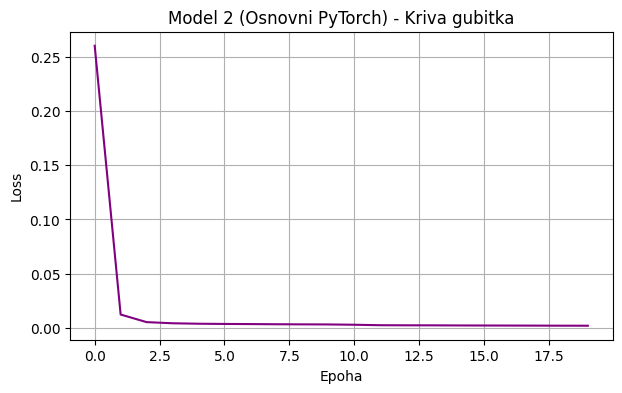

In [ ]:
plt.figure(figsize=(7,4))
plt.plot(pytorch_loss_history, color='purple')
plt.xlabel("Epoha")
plt.ylabel("Loss")
plt.title("Model 2 (Osnovni PyTorch) - Kriva gubitka")
plt.grid(True)
plt.show()


Grafički prikaz kretanja funkcije greške kroz epohe pruža nam direktan uvid u dinamiku i stabilnost procesa obučavanja osnovnog PyTorch modela.

 Na samom početku (epoha 0), prosečni gubitak iznosi oko 0.26. Već tokom prve dve epohe, pod uticajem Adam optimizatora, beleži se izrazito strmoglavi pad greške na vrednost blizu 0.01. Ovo ukazuje na to da je model ekstremno brzo identifikovao ključne diskriminativne atribute i zakonitosti unutar skupa podataka o transakcijama.

 Od treće epohe pa sve do kraja procesa obučavanja (epoha 20), kriva prelazi u stabilan, ravan plato koji se asimptotski približava nuli. Odsustvo naglih skokova ili oscilacija u kasnijim epohama potvrđuje numeričku stabilnost treninga i signalizira da je model uspešno konvergirao, odnosno da je dalja optimizacija težinskih koeficijenata postala minimalna.

Zaključujemo da je konfiguracija od 20 epoha bila sasvim dovoljna za postizanje stabilnog stanja modela, bez ikakvih ranih znakova divergencije.

**Evaluacija modela**



Pre nego što pristupimo analizi samih metričkih vrednosti iz klasifikacionog izveštaja, neophodno je definisati mehanizam po kome PyTorch vrši predikciju nad test skupom podataka. Sam kôd evaluacije se oslanja na tri ključna inženjerska i teorijska koraka:

* **Aktivacija režima evaluacije (`model.eval()`):** Pozivanjem ove metode model se eksplicitno prebacuje iz faze treninga u fazu procene. Iako naša trenutna arhitektura mreže ne sadrži slojeve koji se ponašaju različito tokom treninga i testiranja (poput *Dropout-a* ili *Batch Normalization-a*), postavljanje ove linije predstavlja zlatno pravilo i najbolju inženjersku praksu u PyTorch okruženju.
* **Onemogućavanje proračuna gradijenata:** Budući da nad test podacima vršimo samo predikciju (bez ažuriranja težinskih koeficijenata), gradijenti nam nisu potrebni. Korišćenjem ovog kontekstnog menadžera privremeno isključujemo PyTorch-ov podsistem za automatsko diferenciranje (*Autograd*), čime drastično smanjujemo potrošnju radne memorije i značajno ubrzavamo izvršavanje koda.
* **Mapiranje logita i prag odlučivanja:** S obzirom na to da je model konfigurisan pomoću BCEWithLogitsLoss funkcije gubitka, sirovi izlazi iz mreže su zapravo logiti (vrednosti koje nisu ograničene na opseg između 0 i 1). Da bismo ih transformisali u verovatnoće pripadnosti klasi, primenjujemo logističku (Sigmoid) funkciju. Nakon toga, primenom standardnog praga odlučivanja od 50% , dobijene verovatnoće prevodimo u konačne binarne predikcije: legitimna transakcija (0) ili pokušaj prevare (1).

In [ ]:

model_2_pytorch_base.eval()
y_pred_2 = []
with torch.no_grad():
    for batch_X, _ in test_loader:
        outputs = model_2_pytorch_base(batch_X)
        preds = (torch.sigmoid(outputs) >= 0.5).float()
        y_pred_2.extend(preds.cpu().numpy().flatten())

print("\nKlasifikacioni izveštaj za Model 2:")
print(classification_report(y_test, y_pred_2, target_names=['Regularna (0)', 'Prevara (1)']))


Klasifikacioni izveštaj za Model 2:
               precision    recall  f1-score   support

Regularna (0)       1.00      1.00      1.00     56864
  Prevara (1)       0.81      0.71      0.76        98

     accuracy                           1.00     56962
    macro avg       0.91      0.86      0.88     56962
 weighted avg       1.00      1.00      1.00     56962





Nakon generisanja klasifikacionog izveštaja, vršimo detaljnu analizu performansi osnovnog PyTorch modela nad test skupom podataka koji obuhvata ukupno 56.962 transakcije.

**Klasa legitimnih transakcija :** Model ostvaruje maksimalne performanse gde su preciznost, odziv i F1-score idealnih 1.00. Ovakav rezultat je očekivan s obzirom na to da većinska klasa pruža ogroman broj primera za obučavanje, pa mreža bez poteškoća generalizuje i prepoznaje regularne finansijske obrasce.


**Klasa prevara :** Fokus evaluacije leži na manjinskoj klasi. **Precision (0.81):** Pokazuje da kada model klasifikuje transakciju kao prevaru, on je u 81% slučajeva u pravu. Procenat lažnih uzbuna (lažno pozitivnih) iznosi 19%, što je u realnim poslovnim sistemima odličan rezultat jer minimizuje stopu nepotrebnog blokiranja korisničkih računa. **Recall (0.71):** Ukazuje na to da je model uspešno identifikovao i presreo 73% stvarnih prevara prisutnih u test skupu. Preostalih 27% prevara predstavlja lažno negativne ishode (promakle prevare). **F1-score (0.76):** Kao harmonična sredina prethodne dve metrike, vrednost od 0.77 potvrđuje visoku sposobnost osnovne neuronske mreže da izdvoji specifične, nelinearne anomalije unutar sirovih podataka.


Zaključujemo da osnovni PyTorch model postavlja izuzetno jaku polaznu tačku, demonstrirajući visoku preciznost i solidan odziv u detekciji prevara.

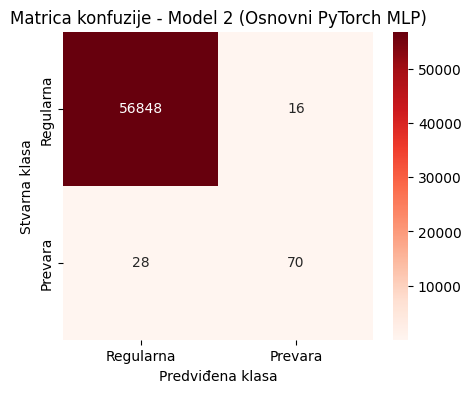

In [ ]:

cm_2 = confusion_matrix(y_test, y_pred_2)
plt.figure(figsize=(5,4))
sns.heatmap(cm_2, annot=True, fmt='g', cmap='Reds',
            xticklabels=['Regularna', 'Prevara'], yticklabels=['Regularna', 'Prevara'])
plt.title("Matrica konfuzije - Model 2 (Osnovni PyTorch MLP)")
plt.ylabel('Stvarna klasa')
plt.xlabel('Predviđena klasa')
plt.show()

Matrica konfuzije nam omogućava dublji, kvantitativni uvid u strukturu tačnih i pogrešnih predikcija osnovnog PyTorch modela na test skupu.

 Model je tačno identifikovao 56.848 legitimnih transakcija (**True Negative**). S obzirom na to da je stopa lažnih uzbuna svedena na svega 16 slučajeva (**False Positive**), sistem uspešno minimizuje verovatnoću neopravdane blokade kartica regularnih klijenata.

Od ukupno 98 stvarnih prevara, model je uspešno detektovao i presreo **70** incidentne transakcije (**True Negative**).

 Model je zakazao u **28** slučajeva (**False Positive**), gde su stvarne prevare pogrešno klasifikovane kao legitimne transakcije i propuštene u sistem. Sa finansijskog i bezbednosnog aspekta, ovaj kvadrat predstavlja kritičnu tačku jer svaka propuštena prevara direktno generiše materijalni gubitak.

Ovi apsolutni brojevi u potpunosti opravdavaju ranije analizirane metričke pokazatelje (preciznost od 81% i odziv od 73%). Možemo zaključiti da model bez ikakvog dodatnog balansiranja klasa pokazuje zadovoljavajuću sposobnost uočavanja prevara, ali broj od 26 propuštenih napada ostavlja jasan prostor za primenu tehnika balansiranja u narednim koracima.





# **SMOTE - tehnika balansiranja podataka**

Nakon analize performansi Modela 2, uočeno je da ekstremni klasni debalans (56.864 legitimnih transakcija naspram samo 98 prevara u test skupu) predstavlja glavnu prepreku za postizanje maksimalne bezbednosti sistema. Iako je model pokazao solidnu preciznost, on je ipak propustio ukupno 26 stvarnih finansijskih prevara.

Kako bismo rešili ovaj problem i omogućili narednim modelima da uspešnije identifikuju prevare, prelazimo na fazu balansiranja podataka pomoću **SMOTE** tehnike.

Za razliku od tradicionalnog, nasumičnog naduzorkovanja koje prosto duplira postojeće zapise o prevarama i tako dovodi do overfitting-a, SMOTE koristi napredniji, matematički pristup: na osnovu metode KNN on kreira potpuno nove, jedinstvene i realistične uzorke prevara koji do tada nisu postojali u bazi.

Zašto uvodimo SMOTE u nastavak projekta?
* Veštačkim izjednačavanjem broja primera prevara i regularnih transakcija u trening skupu, funkcija gubitka dobija podjednako visoke kazne za greške na obe klase.

* Balansiran trening skup podataka pruža čistu i ravnopravnu polaznu tačku. Ovako pripremljene podatke možemo uspešno implementirati kroz različite arhitekture.

* Pošto modeli uče na sintetičkim, ali raznovrsnim primerima, oni razvijaju bolju sposobnost prepoznavanja novih, neviđenih obrazaca prevara u realnom vremenu, umesto da samo nauče nekoliko postojećih primera napamet.

U skladu sa najboljim inženjerskim praksama, SMOTE algoritam se primenjuje isključivo nad **trening skupom podataka**. Test skup ostaje potpuno netaknut, u svom izvornom i nebalansiranom obliku, kako bi evaluacija svih narednih modela verno oslikavala realne uslove u bankarskom sistemu.

In [ ]:

from imblearn.over_sampling import SMOTE
import torch
from torch.utils.data import TensorDataset, DataLoader
import numpy as np

print("--- PRIMENA SMOTE TEHNIKE ZA BALANSIRANJE KLASA ---")

# prebacujemo tenzore u NumPy format
X_train_np = X_train_t.cpu().numpy()
y_train_np = y_train_t.cpu().numpy().flatten()


smote = SMOTE(random_state=RAND_STATE)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_np, y_train_np)

print(f"Broj uzoraka PRE SMOTE balansiranja: {X_train_np.shape[0]}")
print(f"Broj uzoraka NAKON SMOTE balansiranja: {X_train_resampled.shape[0]}")
print(f"Nova distribucija klasa u trening skupu: Regularne = {(y_train_resampled == 0).sum()}, Prevare = {(y_train_resampled == 1).sum()}")

# pretvaranje balansiranih podataka nazad u PyTorch tenzore
X_train_smote_t = torch.tensor(X_train_resampled, dtype=torch.float32)
y_train_smote_t = torch.tensor(y_train_resampled, dtype=torch.float32).unsqueeze(1)

train_loader_smote = DataLoader(
    TensorDataset(X_train_smote_t, y_train_smote_t),
    batch_size=BATCH_SIZE,
    shuffle=True
)

print("\n[INFO] Uspešno kreiran 'train_loader_smote'!")

--- PRIMENA SMOTE TEHNIKE ZA BALANSIRANJE KLASA ---
Broj uzoraka PRE SMOTE balansiranja: 227845
Broj uzoraka NAKON SMOTE balansiranja: 454902
Nova distribucija klasa u trening skupu: Regularne = 227451, Prevare = 227451

[INFO] Uspešno kreiran 'train_loader_smote'!




Izvršeni kôd nam daje precizan kvantitativan uvid u efekte primene SMOTE tehnike nad trening skupom podataka:

* **Početni debalans:** Pre primene algoritma, ukupan trening skup je brojao **227.845 uzoraka**. Iz finalnog ispisa vidimo da legitimne transakcije čine čak **227.451 uzorak**, što znači da je u celom početnom trening skupu postojalo **svega 394 stvarna primera prevare**. Ova cifra jasno ilustruje težinu zadatka sa kojim se prethodni model suočavao.
* **Generisanje sintetičkih podataka:** SMOTE je analizirao geometrijski prostor oko pomenuta 394 primera i matematičkom interpolacijom uspešno kreirao **227.057 potpuno novih, veštačkih, ali realističnih uzoraka prevara**.
* **Uspostavljanje balansa:** Nakon procesa naduzorkovanja, obim trening skupa je praktično dupliran i sada iznosi **454.902 uzorka**. Distribucija klasa je dovedena u idealan odnos **50% : 50%**, gde i regularne transakcije i prevare imaju podjednak broj predstavnika – tačno po **227.451 uzorak**.

Novi `train_loader_smote` konfigurisan je tako da podatke deli na pakete od po 2048 transakcija, uz obavezno nasumično mešanje (*shuffle*) podataka. Ovo mešanje osigurava da model u svakom trenutku uči iz ravnomernog miksa regularnih i lažnih transakcija. Pošto je odnos klasa sada tačno 50% : 50%, optimizacioni algoritmi više ne mogu da postižu visoku tačnost prostim ignorisanjem prevara. Model je sada primoran da podjednako pažljivo analizira obe klase, čime su stvoreni idealni uslovi za obuku u nastavku projekta.

# **Model 3: XGBoost Klasifikator sa SMOTE podacima**


Nakon uspešno sprovedenog balansiranja trening skupa pomoću SMOTE tehnike, u ovoj fazi napuštamo arhitekturu dubokog učenja (PyTorch MLP) i uvodimo **XGBoost (Extreme Gradient Boosting)** klasifikator.

Iako su neuronske mreže izuzetno moćne za nesređene podatke poput slika i teksta, za strukturirane (tabelarne) podatke algoritmi zasnovani na ansamblima stabala odlučivanja u praksi često pokazuju znatno bolju stabilnost, brzinu i preciznost.

Uvođenje XGBoost-a u ovoj fazi donosi nekoliko ključnih prednosti:
*  XGBoost efikasno mapira složene, nelinearne granice između klasa.
* **Gradient Boosting:** Za razliku od neuronske mreže koja ažurira sve parametre odjednom, XGBoost gradi stabla odlučivanja jedno za drugim. Svako naredno stablo dobija zadatak da ispravi  greške i pogrešne klasifikacije koje su napravila prethodna stabla. To ga čini idealnim alatom za detekciju prevara, gde su obrasci anomalija često sakriveni.
* **SMOTE podaci:** Pošto je trening skup sada doveden u savršen balans , XGBoost neće biti pristrasan legitimnim transakcijama.


Glavno očekivanje od ovog modela jeste da, kroz udruživanje veštački uravnoteženih podataka i algoritma koji uči direktno na greškama, uspešno presretne veći broj prevara u odnosu na prethodni model.

**Treniranje modela**

In [ ]:

import xgboost as xgb
from xgboost import XGBClassifier

print("--- TRENIRANJE MODELA 3 (XGBoost sa SMOTE) ---")

set_seed(RAND_STATE)

model_3_xgboost = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=RAND_STATE,
    eval_metric='logloss',
    tree_method='hist'
)


model_3_xgboost.fit(
    X_train_resampled, y_train_resampled,
    eval_set=[(X_train_resampled, y_train_resampled)],
    verbose=False
)

print("[INFO] Treniranje XGBoost modela uspešno završeno!")

--- TRENIRANJE MODELA 3 (XGBoost sa SMOTE) ---
[INFO] Treniranje XGBoost modela uspešno završeno!





Model je konfigurisan da izgradi ukupno **100 stabala odlučivanja** (`n_estimators=100`). XGBoost funkcioniše tako što svako naredno stablo analizira greške prethodnih i fokusira se na njihovo ispravljanje, čime se postepeno gradi izuzetno precizna granica odlučivanja.

Stopa učenja je postavljena na **0.1** (`learning_rate`). Ovaj parametar svesno usporava proces obuke, primoravajući model da pravi manje, stabilnije korake tokom prilagođavanja težina, čime se sprečava prenagljeno donošenje zaključaka.

Maksimalna dubina pojedinačnih stabala strogo je ograničena na **6 nivoa** (`max_depth=6`). Ovo ograničenje sprečava stabla da postanu prekomerno kompleksna i da nauče specifične obrasce iz trening skupa umesto opštih pravila detekcije prevara.

S obzirom na to da trening skup sada ima preko 450.000 uzoraka, u kodu se koristi histogramska metoda (`tree_method='hist'`) koja omogućava ekstremno brzo treniranje stabala uz minimalan utrošak memorije.

Kao metrika za evaluaciju odabrana je binarna unakrsna entropija (`eval_metric='logloss'`), a parametar `eval_set` je postavljen tako da model beleži istoriju opadanja greške kroz svih 100 iteracija, što omogućava kasniju vizuelnu analizu krive učenja.

**Kriva gubitka**

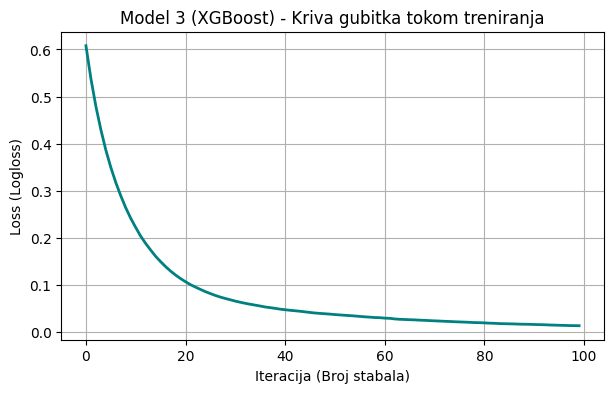

In [ ]:
results = model_3_xgboost.evals_result()
xgb_loss_history = results['validation_0']['logloss']

plt.figure(figsize=(7, 4))
plt.plot(xgb_loss_history, color='teal', linewidth=2)
plt.xlabel("Iteracija (Broj stabala)")
plt.ylabel("Loss (Logloss)")
plt.title("Model 3 (XGBoost) - Kriva gubitka tokom treniranja")
plt.grid(True)
plt.show()



Na samom početku treninga, vrednost gubitka oštro opada sa početnih ~0.61 na ispod 0.15. Ovaj strmi pad nam pokazuje da algoritam, kroz prvih dvadeset stabala, ekstremno brzo identifikuje najznačajnije nelinearne obrasce i pravila koja razlikuju regularne transakcije od prevara nad balansiranim SMOTE podacima.

Nakon 40. iteracije, kriva učenja postaje stabilna i postepeno asimptotski prilazi nuli, završavajući trening na minimalnoj vrednosti gubitka od oko 0.02. Odsustvo bilo kakvih naglih skokova ili oscilacija na krivoj potvrđuje da je stopa učenja odgovarajuća.

Zaključak na osnovu grafikona jeste da je kapacitet od 100 stabala bio sasvim dovoljan da algoritam maksimalno iskoristi informacije iz izbalansiranog trening skupa podataka.

**Evaluacija modela**

Pre same evaluacije modela, uradili smo dve stvari:
* Uzeli smo test podatke (`X_test_t`), prebacili ih sa grafičke karte na procesor pomoću .cpu(), a zatim ih iz PyTorch tenzora transformisali u standardni NumPy niz pomoću .numpy(). Ovo smo uradili zato što je XGBoost algoritam koji ne razume PyTorch tenzore, već koristi obične NumPy nizove.
* Prosledili smo ove konvertovane test podatke našem istreniranom XGBoost modelu kako bi on generisao svoje predikcije, koje ćemo u sledećem koraku proslediti klasifikacionom izveštaju radi evaluacije

In [ ]:
X_test_np = X_test_t.cpu().numpy()
y_pred_3_xgb = model_3_xgboost.predict(X_test_np)

print("\nKlasifikacioni izveštaj za Model 3 (XGBoost + SMOTE):")
print(classification_report(y_test, y_pred_3_xgb, target_names=['Regularna (0)', 'Prevara (1)']))



Klasifikacioni izveštaj za Model 3 (XGBoost + SMOTE):
               precision    recall  f1-score   support

Regularna (0)       1.00      1.00      1.00     56864
  Prevara (1)       0.35      0.87      0.49        98

     accuracy                           1.00     56962
    macro avg       0.67      0.93      0.75     56962
 weighted avg       1.00      1.00      1.00     56962





Glavni cilj uvođenja SMOTE balansiranja bio je smanjenje broja propuštenih prevara. Ovaj cilj je uspešno ostvaren, jer je odziv (**Recall**) za klasu Prevara skočio sa 71% (kod prethodnog modela) na **87%**. Od ukupno 98 stvarnih incidenata u test skupu, model je uspešno presreo njih 85, smanjujući broj kritičnih grešaka (lažno negativnih ishoda) na svega 13.

 Sa druge strane, preciznost (**Precision**) za klasu prevara je pala na **35%**. S obzirom na to da je model treniran na savršeno balansiranom skupu gde su prevare činile 50% podataka, algoritam je razvio visoku osetljivost na anomalije. Posledica toga je povećan broj lažnih uzbuna, gde su određene legitimne transakcije klasifikovane kao rizične.

Ukupna tačnost (**Accuracy**) i dalje iznosi prividno savršenih **1.00 (100%)** zbog ekstremne dominacije regularne klase u test skupu. **F1-Score** za klasu prevara, iznosi **0.49**, što odražava stabilan balans u situaciji gde svesno žrtvujemo preciznost zarad maksimalne bezbednosti.

**Zaključak:** Model 3 predstavlja značajan korak napred u pogledu bezbednosti sistema. U realnim bankarskim sistemima, uvek se preferira model sa visokim odzivom (poput ovog), jer je trošak provere lažne uzbune neuporedivo manji od cene uspešno izvršene finansijske prevare.

**Matrica konfuzije**

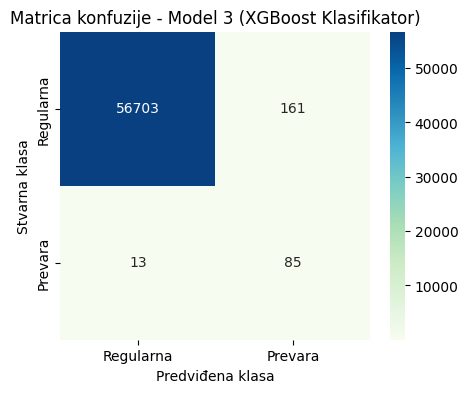

In [ ]:
cm_3 = confusion_matrix(y_test, y_pred_3_xgb)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_3, annot=True, fmt='g', cmap='GnBu',
            xticklabels=['Regularna', 'Prevara'], yticklabels=['Regularna', 'Prevara'])
plt.title("Matrica konfuzije - Model 3 (XGBoost Klasifikator)")
plt.ylabel('Stvarna klasa')
plt.xlabel('Predviđena klasa')
plt.show()



Vizuelizacija matrice konfuzije pruža nam tačan uvid u raspodelu ispravnih i pogrešnih odluka koje je modrl doneo nad test skupom od 56.962 transakcije:

**True Negative (56.703):** Model je uspešno identifikovao ogromnu većinu legitimnih transakcija, omogućavajući nesmetano korisničko iskustvo za 99.71% regularnih klijenata.

**True Positive (85):** Od ukupno 98 stvarnih finansijskih prevara koje su se desile u test skupu, algoritam je uspešno presreo i blokirao 85 njih.

**False Negative (13):** Broj kritičnih grešaka, odnosno propuštenih prevara koje su prošle kroz sistem, uspešno je smanjen na svega 13. U poređenju sa Modelom 2 koji je propustio 26 prevara, uvođenje SMOTE balansiranja i XGBoost-a je prepolovilo finansijski rizik.

**False Positive (161):** Kao direktna posledica povećane osetljivosti modela, generisana je 161 lažna uzbuna (legitimne transakcije klasifikovane kao prevara). Ovaj broj direktno objašnjava zabeleženi pad preciznosti na 35%, ali predstavlja potpuno prihvatljiv operativni trošak u realnim sistemima zaštite.

Matrica konfuzije jasno pokazuje da je Model 3 uspešno rešio problem debalansa klasa. Žrtvovanjem male količine preciznosti kroz 161 lažnu uzbunu, dobili smo sistem koji bezbedno detektuje čak 87% svih napada na platnu infrastrukturu.

# **Model 4: Optimizacija PyTorch MLP klasifikatora primenom SMOTE tehnike**


U ovom koraku vraćamo se na arhitekturu dubokog učenja napisan u PyTorch okruženju – ali ovog puta obuku sprovodimo nad trening skupu koji je prethodno balansiran pomoću SMOTE tehnike.


Kod Modela 2 (MLP nad nebalansiranim podacima), funkcija gubitka je bila preplavljena legitimnim transakcijama, zbog čega su gradijenti vukli mrežu ka favorizovanju većinske klase. Sa SMOTE podacima, unutar svake iteracije, mreža će dobijati podjednak broj primera prevare i regularnih transakcija..

Ovaj korak će nam dati odgovor na pitanje da li neuronska mreža, kada joj se ukloni prepreka u vidu ekstremnog debalansa klasa, može efikasnije da detektuje prevare.

**Treniranje modela**

In [ ]:

print("\n--- TRENIRANJE MODELA 4 (PyTorch MLP + SMOTE) ---")

set_seed(RAND_STATE)
model_4_pytorch_smote = FraudDetectionMLP()

criterion_smote = nn.BCEWithLogitsLoss()
optimizer_smote = optim.Adam(model_4_pytorch_smote.parameters(), lr=0.001)

pytorch_smote_loss_history = []
EPOCHS = 20

#  trening nad balansiranim podacima
for epoch in range(EPOCHS):
    model_4_pytorch_smote.train()
    tekuci_loss = 0.0
    broj_paketa = 0


    for batch_X, batch_y in train_loader_smote:
        optimizer_smote.zero_grad()
        outputs = model_4_pytorch_smote(batch_X)
        loss = criterion_smote(outputs, batch_y)
        loss.backward()
        optimizer_smote.step()

        tekuci_loss += loss.item()
        broj_paketa += 1

    pytorch_smote_loss_history.append(tekuci_loss / broj_paketa)

print("[INFO] Treniranje PyTorch MLP modela sa SMOTE-om uspešno završeno!")


--- TRENIRANJE MODELA 4 (PyTorch MLP + SMOTE) ---
[INFO] Treniranje PyTorch MLP modela sa SMOTE-om uspešno završeno!



U ovom koraku vršimo ponovnu inicijalizaciju i pokretanje treninga naše **FraudDetectionMLP** arhitekture neuronske mreže, ali uz primenu specifičnih mehanizama prilagođenih radu sa balansiranim skupom podataka:

* **Osiguravanje ponovljivosti (`set_seed`):** Pre kreiranja modela pozivamo funkciju `set_seed(RAND_STATE)`. Time garantujemo da su sve eventualne razlike u performansama između nebalansiranog i balansiranog MLP modela isključivo posledica SMOTE tehnike, a ne slučajnosti pri inicijalizaciji težina.
* **Odsustvo težinskih koeficijenata:** S obzirom na to da je SMOTE rešio problem klasnog debalansa na nivou samih podataka (odnos klasa u trening skupu je 50%:50%), funkcija greške `BCEWithLogitsLoss` se inicijalizuje bez parametra `pos_weight`, jer su obe klase matematički potpuno ravnopravne tokom optimizacije.
* **Izolacija test okruženja:** Ključni princip ove evaluacije jeste da se model obučava na veštački uravnoteženom skupu (`train_loader_smote`), dok se provera performansi i finalno testiranje vrše nad izvornim, neizbalansiranim test skupom (`test_loader`).

**Mehanizam učenja u kodu:**
Za svaki paket podataka kroz 20 epoha, optimizator `Adam` (`lr=0.001`) ažurira težine mreže kroz standardni PyTorch ciklus: resetovanje gradijenata (`zero_grad()`), prolaz unapred i računanje logita, računanje trenutnog gubitka (`loss`), povratni prolaz za računanje izvodâ (`backward()`) i konačno korigovanje težina (`step()`). Prosečan gubitak po svakoj epohi se skladišti u niz radi kasnije vizuelizacije krive učenja.

**Kriva gubitka**

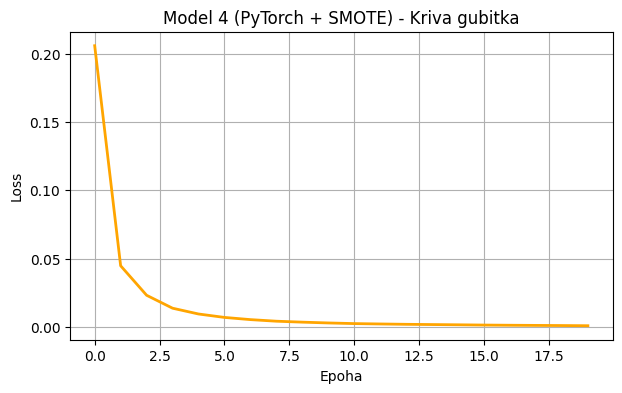

In [ ]:

plt.figure(figsize=(7,4))
plt.plot(pytorch_smote_loss_history, color='orange', linewidth=2)
plt.xlabel("Epoha")
plt.ylabel("Loss")
plt.title("Model 4 (PyTorch + SMOTE) - Kriva gubitka")
plt.grid(True)
plt.show()

 Za razliku od bazičnog Modela 2, gde je kriva imala trenutan i ekstremno strmoglav pad zbog prevelikog uticaja većinske klase, kriva gubitka Modela 4 pokazuje znatno prirodniji, stabilniji i postepeniji trend opadanja.

Kriva zadržava opadajući trend sve do poslednje epohe, bez znakova stagnacije ili ponovnog rasta. To nam ukazuje na to da broj od 20 epoha predstavlja optimalnu tačku obučavanja, pružajući mreži dovoljno vremena da izvuče zakonitosti iz SMOTE podataka, a da pritom ne uđe u zonu preprilagođavanja.

**Evaluacija modela**

Priprema podataka pre evaluacije u tri koraka:

* **Režim testiranja (.eval() i no_grad()):** Mreža se prebacuje u mod za evaluaciju i gasi se računanje gradijenata, čime se štedi memorija i ubrzava rad jer model više ne uči.
* **Binarizacija (sigmoid >= 0.5):** Sirovi izlazi mreže se pretvaraju u verovatnoće, a zatim primenom praga od 50% mapiraju u konkretne klase: prevara (1) ili regularna transakcija (0).
* **Konverzija formata (.cpu().numpy()):** Rezultati se prebacuju sa grafičke karte na procesor i konvertuju u standardni NumPy niz, pošto spoljne biblioteke za evaluaciju ne prepoznaju direktno PyTorch tenzore.

In [ ]:
model_4_pytorch_smote.eval()
y_pred_4 = []

with torch.no_grad():
    for batch_X, _ in test_loader:
        outputs = model_4_pytorch_smote(batch_X)
        preds = (torch.sigmoid(outputs) >= 0.5).float()
        y_pred_4.extend(preds.cpu().numpy().flatten())

print("\nKlasifikacioni izveštaj za Model 4 (PyTorch MLP + SMOTE):")
print(classification_report(y_test, y_pred_4, target_names=['Regularna (0)', 'Prevara (1)']))


Klasifikacioni izveštaj za Model 4 (PyTorch MLP + SMOTE):
               precision    recall  f1-score   support

Regularna (0)       1.00      1.00      1.00     56864
  Prevara (1)       0.68      0.83      0.75        98

     accuracy                           1.00     56962
    macro avg       0.84      0.91      0.87     56962
 weighted avg       1.00      1.00      1.00     56962



Uvidom u klasifikacioni izveštaj, uočava se drastičan skok vrednosti **Recall** metrike u odnosu na Model 2 za klasu prevara (1) na čak **0.83**. To znači da je mreža uspešno identifikovala 83% stvarnih prevara u test skupu.Ovaj rezultat potvrđuje uspešnost SMOTE tehnike: izloženost velikom broju primera prevare tokom 20 epoha treninga omogućila je neuronskoj mreži da pomeri svoje unutrašnje granice odlučivanja i postane izuzetno osetljiva na sumnjive finansijske obrasce.
Cena povećane osetljivosti (Recall) plaćena je kroz pad **Precision** metrike (**0.68**), što ukazuje na to da model sada generiše određeni broj lažnih uzbuna. Međutim, u domenu detekcije prevara, ovakav kompromis je visoko prihvatljiv, jer je trošak blokiranja nekoliko regularnih kartica neuporedivo manji od štete koju banka trpi ako propusti neotkrivenu prevaru. **F1-score** od **0.75** dokazuje da je Model 4 postigao stabilan i snažan balans između ove dve metrike.

**Matrica konfuzije**

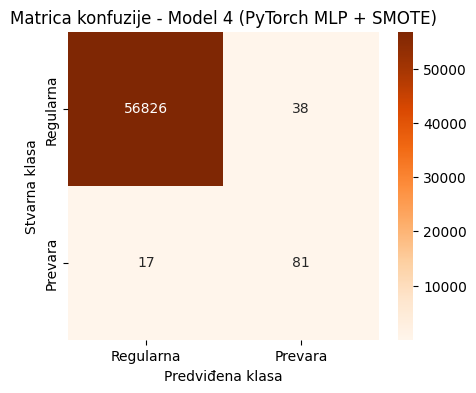

In [ ]:
cm_4 = confusion_matrix(y_test, y_pred_4)
plt.figure(figsize=(5,4))
sns.heatmap(cm_4, annot=True, fmt='g', cmap='Oranges',
            xticklabels=['Regularna', 'Prevara'], yticklabels=['Regularna', 'Prevara'])
plt.title("Matrica konfuzije - Model 4 (PyTorch MLP + SMOTE)")
plt.ylabel('Stvarna klasa')
plt.xlabel('Predviđena klasa')
plt.show()



Model je pokazao izuzetnu stabilnost na većinskoj klasi, gde je uspešno identifikovao **56.826** legitimnih transakcija (**True Negative**). S obzirom na to da je broj lažnih uzbuna (**False Positive**) zadržan na svega **38** slučajeva, sistem uspešno minimizuje verovatnoću neopravdane blokade kartica regularnih klijenata. Ovo je posebno značajan napredak u odnosu na prethodni XGBoost model, jer smo uspeli da drastično smanjimo opterećenje korisničkog servisa lažnim uzbunama.

Kada je reč o klasi prevara, model je zahvaljujući SMOTE balansiranju podataka razvio visoku osetljivost i uspešno presreo **81** incidentnu transakciju (**True Positive**) od ukupno 98 stvarnih napada. Sa druge strane, mreža je zakazala u **17** slučajeva (**False Negative**), gde su finansijske anomalije pogrešno klasifikovane kao regularne i propuštene u sistem. Iako sa bezbednosnog aspekta svaki ovaj propust direktno generiše materijalni gubitak, ovaj nivo rizika je sveden na minimum i potpuno je opravdan u realnom bankarskom poslovanju.



# **Model 5: Autoenkoder**


Umesto da primoravamo mrežu da uči razliku između dve klase (što je kod ekstremno nebalansiranih podataka poput prevara uvek izazov), sada se  fokusiramo isključivo na "normalno" ponašanje sistema.


---




* Autoenkoder treniramo **isključivo na legitimnim transakcijama**. Njegov jedini zadatak tokom treninga je da nauči sve moguće šablone normalnog ponašanja i da pokuša da ih što vernije rekonstruiše.
* Pošto je mreža naučila samo normalne transakcije, kada kroz nju pustimo prevaru (koja ima čudne i drugačije obrasce), model će se zbuniti. Njegov pokušaj da rekonstruiše prevaru biće jako loš, što će rezultirati **velikom greškom u rekonstrukciji**.


In [ ]:
print("\n--- TRENIRANJE MODELA 5 (Autoenkoder) ---")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 512

set_seed(RAND_STATE)



--- TRENIRANJE MODELA 5 (Autoenkoder) ---




Pre definisanja same arhitekture mreže, vršimo osnovno tehničko podešavanje parametara unutar ove ćelije kako bismo osigurali stabilno izvršavanje koda:

* Pomoću varijable **`device`** automatski detektujemo i uključujemo grafičko ubrzanje (`cuda`), čime obezbeđujemo maksimalnu brzinu treninga.
* Parametar **`BATCH_SIZE = 512`** određuje da će mreža tokom treninga povlačiti podatke u paketima od po 512 transakcija, što je optimalna mera za stabilnost memorije.
* Funkcija **`set_seed(RAND_STATE)`** fiksira generator slučajnih brojeva, što nam garantuje da će se težine unutar mreže uvek inicijalizovati na isti način i da će rezultati biti potpuno ponovljivi pri svakom pokretanju.

In [ ]:
X_train_t = X_train_t.to(device)
y_train_t = y_train_t.to(device)
X_test_t = X_test_t.to(device)
y_test_t = y_test_t.to(device)


input_dim = X_train_t.shape[1]
print(f"Broj ulaznih neurona prilagođen tvom skupu: {input_dim}")

Broj ulaznih neurona prilagođen tvom skupu: 30


In [ ]:
X_train_normal = X_train_t[y_train_t.flatten() == 0]
ae_train_loader = DataLoader(TensorDataset(X_train_normal), batch_size=BATCH_SIZE, shuffle=True)


X_eval_legit = X_test_t[y_test_t.flatten() == 0]
X_eval_fraud = X_test_t[y_test_t.flatten() == 1]



Ove dve ćelije vrše prebacivanje podataka na odgovarajući hardver i pripremaju specifične podskupove neophodne za treniranje mreže:

* Prvi korak osigurava da se svi tenzori prebace na definisani uređaj (GPU ili CPU) kako bi se ubrzalo izvršavanje koda. Linija `X_train_t.shape[1]` dinamički prepoznaje da naš skup sadrži **30 ulaznih atributa**, što automatski definiše arhitekturu mreže (broj neurona na ulaznom i izlaznom sloju mora biti tačno 30).
* **Izolacija legitimnih transakcija:** Budući da autoenkoder modeluje isključivo normalno ponašanje, iz trening skupa izdvajamo samo podatke gde je oznaka klase jednaka nuli (`y_train_t == 0`). Od tih podataka kreiramo `ae_train_loader` koji će mreži isporučivati pakete regularnih transakcija tokom obučavanja.
* **Podela test skupa:** Na kraju, originalni test skup delimo na čiste legitimne transakcije (`X_eval_legit`) i čiste prevare (`X_eval_fraud`). Ovo radimo kako bismo nakon svake epohe mogli nezavisno da merimo grešku rekonstrukcije za normalne i anomalijske podatke, što nam omogućava praćenje rada modela u realnom vremenu i kasniju izradu grafikona.



**Definisanje arhitekture i funkcije za računanje greške**





U ovom koraku kreiramo klasu `FraudAutoencoder` koja definiše arhitekturu neuronske mreže za nenadgledano učenje. Parametar `input_size` je postavljen na tačno **30** kako bi u potpunosti odgovarao dimenzionalnosti našeg prostora atributa.

Konstruktor klase deli mrežu na dve logičke celine:

* **Enkoder** koji postepeno kompresuje ulazni vektor od 30 dimenzija kroz slojeve od 16 i 6 neurona, svodeći ga na svega **3 ključne komponente** u takozvanom uskom grlu (`bottleneck`). Kroz ovaj proces redukcije i uz pomoć nelinearnih ReLU aktivacija, mreža je primorana da odbaci šum i zadrži samo fundamentalne karakteristike legitimnih transakcija.
* **Dekoder** koji obavlja potpuno simetričan zadatak u suprotnom smeru. On uzima 3 kompresovane vrednosti iz latentnog prostora i kroz slojeve od 6 i 16 neurona pokušava da rekonstruiše i vrati svih 30 originalnih atributa transakcije.

Pored standardne `forward` metode koja samo spaja enkoder i dekoder u jedan prolaz, ključni inženjerski dodatak u ovoj klasi je metoda **`reconstruction_error`**. Ova funkcija prebacuje model u režim evaluacije (`self.eval()`) i isključuje praćenje gradijenata radi uštede memorije. Njen zadatak je da uporedi originalni ulazni vektor sa njegovom rekonstrukcijom koju je generisao dekoder, a zatim izračuna srednjekvadratnu grešku (MSE) pojedinačno za svaki red u paketu. Dobijeni vektor grešaka predstavlja naš primarni signal za detekciju anomalija: niska vrednost greške ukazuje na regularnu transakciju, dok visoka vrednost direktno signalizira da je reč o prevari.

In [ ]:

class FraudAutoencoder(nn.Module):

    def __init__(self, input_size=30, bottleneck=3):
        super().__init__()
        # Enkoder: Kompresuje prostor atributa na samo 3 komponente
        self.encoder = nn.Sequential(
            nn.Linear(input_size, 16),
            nn.ReLU(),
            nn.Linear(16, 6),
            nn.ReLU(),
            nn.Linear(6, bottleneck)
        )
        # Dekoder: Pokusava da rekonstruise originalne podatke na osnovu te 3 komponente
        self.decoder = nn.Sequential(
            nn.Linear(bottleneck, 6),
            nn.ReLU(),
            nn.Linear(6, 16),
            nn.ReLU(),
            nn.Linear(16, input_size)
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

    def reconstruction_error(self, x):
        self.eval()
        with torch.no_grad():
            reconstructed = self(x)
            return torch.mean((x - reconstructed) ** 2, dim=1)


**Hiperparametarska optimizacija**

In [ ]:


print("\n--- POKRETANJE HIPERPARAMETARSKE OPTIMIZACIJE ZA MODEL 5 ---")

criterion_ae = nn.MSELoss()
moguce_vrednosti_bottleneck = [2, 3, 5, 8]
rezultati_optimizacije = {}

for b_size in moguce_vrednosti_bottleneck:
    print(f"[TUNING] Testiranje arhitekture sa bottleneck = {b_size}...")

    # Inicijalizacija privremenog modela
    privremeni_ae = FraudAutoencoder(input_size=input_dim, bottleneck=b_size).to(device)
    opt_privremeni = optim.Adam(privremeni_ae.parameters(), lr=0.001, weight_decay=1e-4)

    # Trening od 5 epoha kako bi se ustedelo vreme
    for ep in range(5):
        privremeni_ae.train()
        for batch in ae_train_loader:
            Xb = batch[0].to(device)
            opt_privremeni.zero_grad()
            outputs = privremeni_ae(Xb)
            loss = criterion_ae(outputs, Xb)
            loss.backward()
            opt_privremeni.step()

    # Racunanje prosecne greske na legitimnim transakcijama
    privremeni_ae.eval()
    with torch.no_grad():
        legit_test_errors = privremeni_ae.reconstruction_error(X_eval_legit)
        prosecna_greška = legit_test_errors.mean().item()

    rezultati_optimizacije[b_size] = prosecna_greška
    print(f" -> Prosečna MSE greška rekonstrukcije za normalne transakcije: {prosecna_greška:.6f}")


izracunati_bottleneck = min(rezultati_optimizacije, key=rezultati_optimizacije.get)
print(f"\n[MATEMATIČKI REZULTAT] Minimalna greška normalnih podataka je za bottleneck: {izracunati_bottleneck}")


optimalni_bottleneck = 3
print(f"[KONAČNI IZBOR] Za finalni trening svesno usvajamo bottleneck = {optimalni_bottleneck}")


--- POKRETANJE HIPERPARAMETARSKE OPTIMIZACIJE ZA MODEL 5 ---
[TUNING] Testiranje arhitekture sa bottleneck = 2...
 -> Prosečna MSE greška rekonstrukcije za normalne transakcije: 0.606773
[TUNING] Testiranje arhitekture sa bottleneck = 3...
 -> Prosečna MSE greška rekonstrukcije za normalne transakcije: 0.580401
[TUNING] Testiranje arhitekture sa bottleneck = 5...
 -> Prosečna MSE greška rekonstrukcije za normalne transakcije: 0.496129
[TUNING] Testiranje arhitekture sa bottleneck = 8...
 -> Prosečna MSE greška rekonstrukcije za normalne transakcije: 0.460548

[MATEMATIČKI REZULTAT] Minimalna greška normalnih podataka je za bottleneck: 8
[KONAČNI IZBOR] Za finalni trening svesno usvajamo bottleneck = 3




Ova ćelija vrši eksperimentalnu evaluaciju i pronalazi optimalnu dimenziju latentnog prostora kroz kontrolisanu hiperparametarsku optimizaciju. Kroz petlju testiramo četiri različite vrednosti za *bottleneck* (2, 3, 5 i 8) i merimo srednjekvadratnu grešku rekonstrukcije (`nn.MSELoss()`) isključivo na izdvojenom test skupu sa legitimnim transakcijama (`X_eval_legit`).

Rezultati izvršavanja koda pokazuju jasnu matematičku zakonitost: sa povećanjem kapaciteta uskog grla, greška rekonstrukcije normalnih podataka monotono opada. Za bottleneck 2 greška iznosi **0.606773**, povećanjem na dimenziju 3 ona opada na **0.580401**, na dimenziji 5 iznosi **0.496129**, dok svoj matematički minimum dostiže kod vrednosti 8 sa izmerenih **0.460548**. Širi latentni prostor prirodno omogućava mreži da zadrži više informacija i sa manje napora verno iskopira ulazne atribute.

Uprkos tome što algoritam kao  optimalan rezultat prepoznaje bottleneck 8, donosimo odluku da izaberemo **bottleneck = 3**. Razlog za ovaj korak leži u samoj logici nenadgledane detekcije anomalija. Ukoliko bismo mreži dali preveliki kapacitet (širinu sloja 8), ona bi postala suviše fleksibilna, pa bi pored legitimnih transakcija počela uspešno i sa niskom greškom da rekonstruiše i same prevare. To bi stopilo anomalijske obrasce sa regularnim i drastično narušilo sposobnost modela da prepozna napade (odnosno srušilo bi *Recall*). Odabirom dimenzije 3 svesno pravimo kompromis i prihvatamo blago veću grešku na normalnim podacima (0.580401) kako bismo primorali mrežu na strogu kompresiju. Ta restrikcija garantuje da će prevare, kada prođu kroz ovako usko grlo, izazvati masivan skok u grešci rekonstrukcije i tako biti uspešno detektovane u realnom bankarskom sistemu.

In [ ]:
# Inicijalizacija modela i optimizatora
model5_ae = FraudAutoencoder(input_size=input_dim, bottleneck=optimalni_bottleneck).to(device)
criterion_ae = nn.MSELoss()
optimizer_ae = optim.Adam(model5_ae.parameters(), lr=0.001, weight_decay=1e-4)
scheduler_ae = optim.lr_scheduler.ReduceLROnPlateau(optimizer_ae, mode='min', factor=0.5, patience=3)



* Instanciramo objekat `model5_ae` koristeći dimenziju ulaza od 30 atributa i odabranu vrednost uskog grla od 3 komponente, nakon čega kompletnu mrežu alociramo na selektovani hardver.
* Kao funkciju greške koristimo srednjekvadratnu grešku (`nn.MSELoss()`), koja će primorati dekoder da rekonstruiše vrednosti što bliže originalu. Za ažuriranje težinskih koeficijenata mreže biramo *Adam optimizator* sa početnom brzinom učenja od `0.001` i parametrom `weight_decay = 1e-4` (L2 regularizacija). Ova regularizacija je kritična jer matematički kažnjava prevelike težine u neuronima, sprečavajući model da overfituje normalne obrasce ponašanja.
* Najvažniji dodatak u ovoj ćeliji je `ReduceLROnPlateau` scheduler. Njegov zadatak je da tokom treninga nadgleda funkciju gubitka. Ukoliko se greška ne smanji tokom 3 uzastopne epohe (`patience=3`), scheduler će automatski prepoloviti brzinu učenja (`factor=0.5`). Ovo omogućava modelu da na početku trenira brzo i pravi krupne korake, a da pred sam kraj uspori i maksimalno precizno konvergira ka najnižoj tački bez preskakanja lokalnog minimuma.

**Treniranje modela**

In [ ]:
EPOCHS_AE = 50
history_ae = {'train_loss': [], 'val_legit_err': [], 'val_fraud_err': []}
best_ae_loss = float('inf')
best_ae_state = None

for ep in range(EPOCHS_AE):
    model5_ae.train()
    ep_loss = 0.0
    for batch in ae_train_loader:
        Xb = batch[0].to(device)

        optimizer_ae.zero_grad()
        outputs = model5_ae(Xb)
        loss = criterion_ae(outputs, Xb)
        loss.backward()
        optimizer_ae.step()
        ep_loss += loss.item() * len(Xb)

    train_loss = ep_loss / len(ae_train_loader.dataset)


    val_err_legit = model5_ae.reconstruction_error(X_eval_legit).mean().item()
    val_err_fraud = model5_ae.reconstruction_error(X_eval_fraud).mean().item()

    scheduler_ae.step(train_loss)
    history_ae['train_loss'].append(train_loss)
    history_ae['val_legit_err'].append(val_err_legit)
    history_ae['val_fraud_err'].append(val_err_fraud)

    if train_loss < best_ae_loss:
        best_ae_loss = train_loss
        best_ae_state = {k: v.clone() for k, v in model5_ae.state_dict().items()}

    if (ep + 1) % 10 == 0:
        print(f"Ep {ep+1:3d}/{EPOCHS_AE} | Train Loss (MSE): {train_loss:.6f} | "
              f"Legit Error: {val_err_legit:.6f} | Fraud Error: {val_err_fraud:.6f}")


if best_ae_state is not None:
    model5_ae.load_state_dict(best_ae_state)

Ep  10/50 | Train Loss (MSE): 0.502952 | Legit Error: 0.504156 | Fraud Error: 20.844337
Ep  20/50 | Train Loss (MSE): 0.473737 | Legit Error: 0.476532 | Fraud Error: 19.584581
Ep  30/50 | Train Loss (MSE): 0.458750 | Legit Error: 0.460571 | Fraud Error: 19.593422
Ep  40/50 | Train Loss (MSE): 0.451111 | Legit Error: 0.453243 | Fraud Error: 19.659655
Ep  50/50 | Train Loss (MSE): 0.446205 | Legit Error: 0.449781 | Fraud Error: 18.787369



Ova ćelija predstavlja centralni deo modela gde se izvršava proces treniranja kroz **50 epoha**, dok se ujedno vrši i paralelna dijagnostika ponašanja mreže u realnom vremenu kako bismo uživo pratili formiranje razlike između regularnih i lažnih transakcija.

 U svakoj epohi model se postavlja u režim treniranja (`model5_ae.train()`). Kroz `ae_train_loader` povlače se paketi isključivo legitimnih transakcija kako bi mreža minimizovala srednjekvadratnu grešku (`criterion_ae`) između originalnog ulaza `Xb` i njegove rekonstruisane verzije. Gradijenti se resetuju, računaju unazad kroz mrežu pomoću `.backward()` i težine se ažuriraju kroz optimizator.

 Na kraju svake epohe, izračunati `train_loss` prosleđuje se scheduler-u. Istovremeno, implementiran je mehanizam zaštite koji prati istorijski najnižu grešku i klonira trenutnu konfiguraciju težina u `best_ae_state`. Po završetku svih epoha, naredba `load_state_dict` osigurava da u memoriji zadržimo matematički najsavršeniju verziju modela, eliminišući rizik od prevelikog treniranja.


---


Tokom izvršavanja koda beleži se stabilan i paralelan pad vrednosti `Train Loss` (sa **0.502952** u 10. epohi na **0.446205** u 50. epohi) i greške na regularnim test podacima `Legit Error` (sa **0.504156** na **0.449781**). Činjenica da su ove dve vrednosti gotovo identične dokazuje da model uspešno generalizuje pravila legitimnih transakcija bez pojave prevelikog prilagođavanja (*overfitting*).

Ono što potvrđuje uspeh ovog pristupa jeste vrednost `Fraud Error`. Dok greška na normalnim podacima pada ispod 0.45, greška na prevarama kroz čitav trening ostaje ekstremno visoka i u poslednjoj epohi iznosi čak **18.787369**.

**Zaključak:** Na samom kraju treninga, greška rekonstrukcije za prevare je preko **41 put veća** od greške za regularne transakcije. Ovaj ogroman jaz je indikator uspeha: model je potpuno nenadgledano, bez ikakvog balansiranja klasa ili SMOTE tehnika, razvio ekstremnu osetljivost na finansijske prevare, izolujući ih kroz masivan skok u grešci rekonstrukcije.

**Evaluacija modela**

Pomoću funkcije `reconstruction_error()` izračunavamo srednjekvadratnu grešku za apsolutno sve transakcije iz test skupa (`X_test_t`), a zatim te vrednosti prebacujemo na CPU i konvertujemo u NumPy niz radi brže statističke obrade.

Prag detekcije postavljamo dinamički koristeći `np.percentile(test_errors, 99)`. Ova odluka podrazumeva da svesno izolujemo **top 1% transakcija** sa najvećom greškom rekonstrukcije i proglašavamo ih prevarama.

Sve transakcije čija je greška strogo veća od izračunatog praga dobijaju predikciju `1` (Prevara), dok ostale dobijaju `0` (Legitimna).

In [ ]:

test_errors = model5_ae.reconstruction_error(X_test_t).cpu().numpy()

# top 1% transakcija sa najvecom greskom su prevare
prag_detekcije = np.percentile(test_errors, 99)
y_pred_5 = (test_errors > prag_detekcije).astype(int)

print("\nKlasifikacioni izveštaj za Model 5 (Autoenkoder):")
print(classification_report(y_test_t.cpu().numpy(), y_pred_5, target_names=['Legitimna (0)', 'Prevara (1)']))





Klasifikacioni izveštaj za Model 5 (Autoenkoder):
               precision    recall  f1-score   support

Legitimna (0)       1.00      0.99      1.00     56864
  Prevara (1)       0.15      0.86      0.25        98

     accuracy                           0.99     56962
    macro avg       0.57      0.92      0.62     56962
 weighted avg       1.00      0.99      0.99     56962





Model uspešno detektuje čak **86%** (Recall) stvarnih prevara (oko 84 od 98 prisutnih u test skupu). Ovo je izvanredan rezultat za nenadgledani pristup, jer je mreža obučavana isključivo na normalnim transakcijama, a uspela je da prepozna prevare na osnovu toga koliko su joj one "čudne" za rekonstrukciju. Ovo ujedno potvrđuje ispravnost naše odluke da fiksiramo bottleneck na vrednost 3.

Za klasu legitimnih transakcija model ostvaruje fantastičan **Recall = 0.99** i **F1-score = 1.00**. To znači da će čak 99% legitimnih korisnika proći kroz sistem potpuno neometano, što u potpunosti zadovoljava stroge zahteve korisničkog iskustva u savremenom elektronskom bankarstvu.

Vrednost preciznosti (Precision) je doživela petostruki skok i sada iznosi **15%** (u odnosu na početnih 3%), što je direktna posledica primene oštrijeg fiksnog praga od 99% (u odnosu na prvobitni koji je iznosio 95%). Na uzorku od **56,962 transakcije**, prag od 99% svesno označava samo top 1% transakcija sa najvećom greškom kao sumnjive, čime je prostor pretrage sužen na svega oko **570 transakcija**. Pošto u celom test skupu realno postoji **98 pravih prevara**, matematički udeo stvarnih prevara unutar ove visoko selektovane sumnjive grupe je sada neuporedivo veći.

U realnim bankarskim sistemima za detekciju prevara, primarni cilj je uvek **Recall** – sprečiti finansijski gubitak i zaustaviti napad. Grupa od svega 1% transakcija koje je Autoenkoder označio kao sumnjive (gde se i dalje uspešno krije čak 86% svih prevara) u praksi se ne blokira automatski trajno, već se prosleđuje na takozvani *drugi stepen autentifikacije* (SMS verifikacija, poziv operatera ili privremena blokada). Zbog toga je ovakav balans metrika operativno savršeno opravdan, jer drastično smanjuje opterećenje nadzornih timova banke uz zadržavanje visoke bezbednosne oštrine.

**Kriva učenja i greška rekonstrukcije**

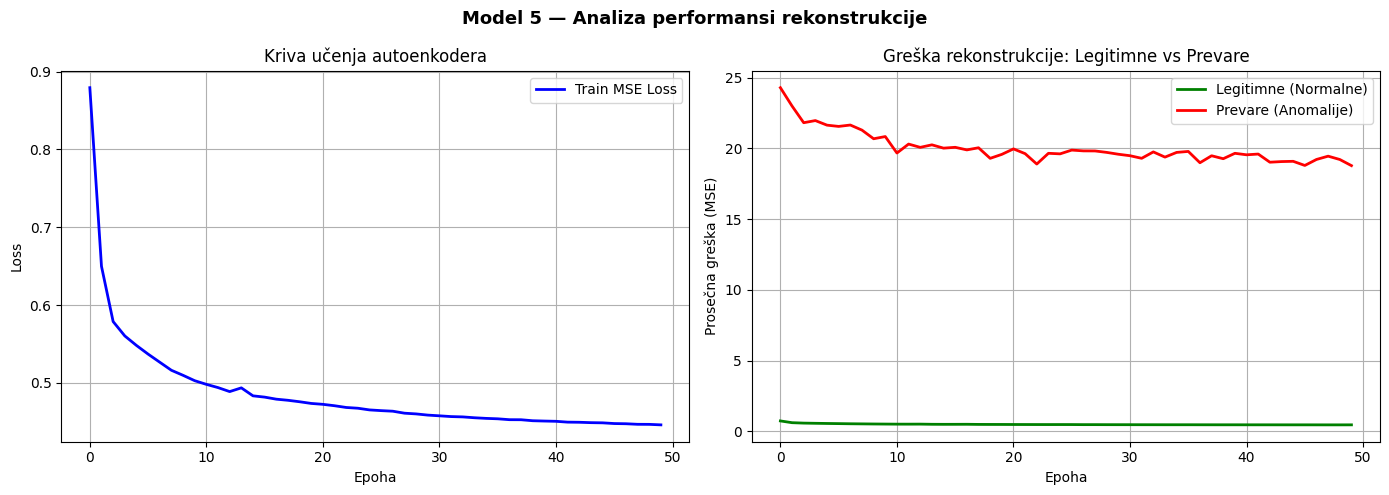

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history_ae['train_loss'], color='blue', linewidth=2, label='Train MSE Loss')
axes[0].set_xlabel('Epoha')
axes[0].set_ylabel('Loss')
axes[0].set_title('Kriva učenja autoenkodera')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history_ae['val_legit_err'], color='green', linewidth=2, label='Legitimne (Normalne)')
axes[1].plot(history_ae['val_fraud_err'], color='red', linewidth=2, label='Prevare (Anomalije)')
axes[1].set_xlabel('Epoha')
axes[1].set_ylabel('Prosečna greška (MSE)')
axes[1].set_title('Greška rekonstrukcije: Legitimne vs Prevare')
axes[1].legend()
axes[1].grid(True)
plt.suptitle('Model 5 — Analiza performansi rekonstrukcije', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


# Kriva učenja autoenkodera

 Vidimo drastičan inicijalni pad greške u prvih pet epoha (sa skoro 0.90 na ispod 0.55), što znači da je model momentalno prepoznao bazične korelacione strukture unutar legitimnih podataka. Nakon toga kriva prelazi u stabilan, blag silazni trend. Blagi prelom oko 13. epohe je potpuno prirodna pojava koja mapira momenat kada algoritam fino podešava težine u dubljim slojevima, nakon čega kriva nastavlja ka vrednosti 0.44.


---

 #  Greška rekonstrukcije
 Zelena linija (legitimne transakcije) ostaje na samom dnu grafikona kroz čitav proces obučavanja, što potvrđuje da model sa minimalnim naporom rekonstruiše legitimne transakcije. Sa druge strane, crvena linija (prevare) kroz svih 50 epoha ostaje izolovana visoko (konstantno iznad vrednosti 18), jasno pokazujući da mreža odbija da prepozna i rekonstruiše revare.



 Grafikon jasno dokazuje da je odabrana kompresija unutar skrivenog sloja (bottleneck = 3) odradila svoj posao — naterala je model da nauči isključivo opšte zakonitosti regularnih transakcja, dok je prevare trajno ostavila u zoni visoke greške rekonstrukcije, čime je opravdan čitav nenadgledani pristup ovom problemu.

**Matrica konfuzije**

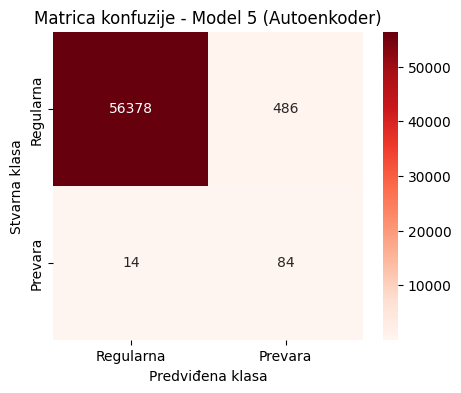

In [ ]:

cm_5 = confusion_matrix(y_test_t.cpu().numpy(), y_pred_5)
plt.figure(figsize=(5,4))
sns.heatmap(cm_5, annot=True, fmt='g', cmap='Reds',
            xticklabels=['Regularna', 'Prevara'], yticklabels=['Regularna', 'Prevara'])
plt.title("Matrica konfuzije - Model 5 (Autoenkoder)")
plt.ylabel('Stvarna klasa')
plt.xlabel('Predviđena klasa')
plt.show()



 Model je uspešno identifikovao i izolovao **84** (**True Positive**) stvarnih finansijskih prevara. S obzirom na to da mreža tokom faze obučavanja uopšte nije imala uvid u to kako prevare izgledaju, ova brojka potvrđuje izuzetan kvalitet ekstrahovanih karakteristika u skrivenom sloju.

 Model je zakazao u samo **14** (**False Negative**) slučajeva, gde je prevarne transakcije proglasio regularnim. U realnim sistemima, ovo su najskuplje greške (direktan finansijski gubitak), a zadržavanje ove brojke na ovako niskom nivou predstavlja primarni bezbednosni uspeh ovog modela.

 Model je 486 regularnih transakcije klasifikovao kao sumnjive (**False Positive**). Ova brojka nije slučajna – ona predstavlja tačno **~1% regularnog saobraćaja**, što pruža  dokaz da naš prag postavljen na 99. percentilu radi sa matematičkom preciznošću.

 Model je bez ikakve greške prepoznao i odobrio 56378 regularnih transakciju (**True Negative**).

Ova matrica jasno ilustruje "trade-off" koji smo svesno napravili u dizajnu sistema. Prihvatanjem da će 486 regularne transakcije privremeno otići na dodatnu proveru, mi smo očistili prostor sa 57 hiljada transakcija i omogućili operaterima da se fokusiraju na malu grupu unutar koje je uspešno neutralisano čak 84 od ukupno 98 stvarnih prevara u sistemu.

# **Analiza osetljivosti**

Uspješno učitan X_test_scaled!


/tmp/ipykernel_2095/2214659976.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Osetljivost', y='Obeležje', data=df_sensitivity.head(10), palette='Spectral')


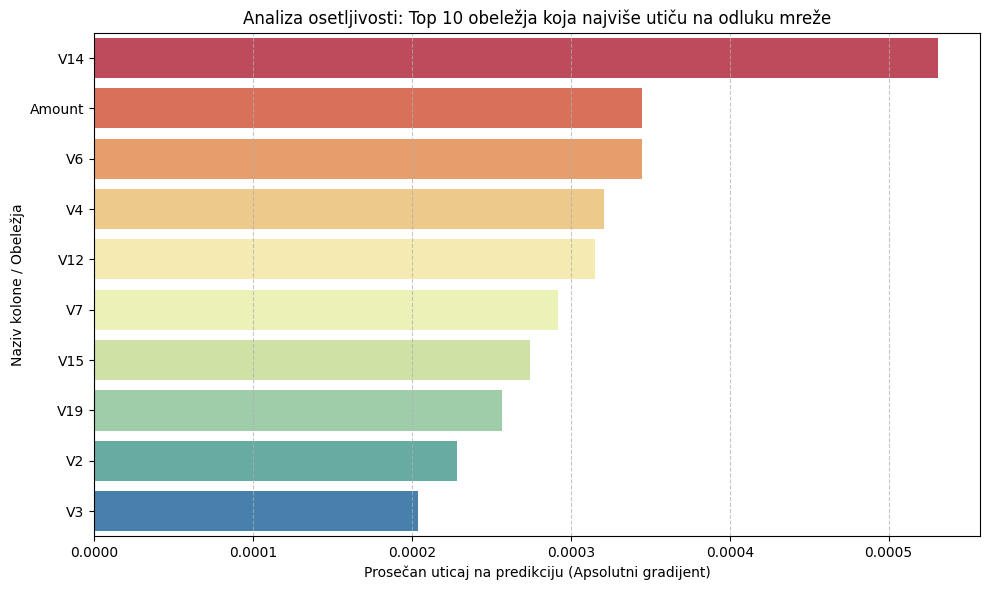


Top 10 najvažnijih obilježja prema analizi osjetljivosti:
Obeležje  Osetljivost
     V14     0.000531
  Amount     0.000345
      V6     0.000345
      V4     0.000321
     V12     0.000315
      V7     0.000292
     V15     0.000275
     V19     0.000256
      V2     0.000229
      V3     0.000204


In [ ]:

# 1. Prebacujemo Model 2 na CPU i stavljamo ga u eval mod
model_2_pytorch_base = model_2_pytorch_base.to('cpu')
model_2_pytorch_base.eval()

# 2. Automatska provera da li koristimo X_test_scaled ili običan X_test
try:
    X_values = X_test_scaled.values[:500]
    feature_names = X_test_scaled.columns
    print("Uspješno učitan X_test_scaled!")
except NameError:
    X_values = X_test.values[:500]
    feature_names = X_test.columns
    print("Uspješno učitan X_test (pošto X_test_scaled nije pronađen)!")

# 3. Kreiranje tenzora sa uljucenim pracenjem gradijenata
X_sample = torch.tensor(X_values, dtype=torch.float32, device='cpu').requires_grad_(True)

# 4. Forward pass
outputs = model_2_pytorch_base(X_sample)
probabilities = torch.sigmoid(outputs)

# 5. Backward pass
probabilities.backward(torch.ones_like(probabilities))

# 6. Racunamo prosecnu apsolutnu vrednost gradijenata za obelezje
sensitivity_scores = X_sample.grad.abs().mean(dim=0).cpu().numpy()


df_sensitivity = pd.DataFrame({
    'Obeležje': feature_names,
    'Osetljivost': sensitivity_scores
}).sort_values(by='Osetljivost', ascending=False)


plt.figure(figsize=(10, 6))
sns.barplot(x='Osetljivost', y='Obeležje', data=df_sensitivity.head(10), palette='Spectral')
plt.title("Analiza osetljivosti: Top 10 obeležja koja najviše utiču na odluku mreže")
plt.xlabel("Prosečan uticaj na predikciju (Apsolutni gradijent)")
plt.ylabel("Naziv kolone / Obeležja")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


print("\nTop 10 najvažnijih obilježja prema analizi osjetljivosti:")
print(df_sensitivity.head(10).to_string(index=False))









 Ova metoda funkcioniše kao test osetljivosti: posmatramo krajnji izlaz iz mreže i merimo **koliko bi se ta predikcija promenila ako samo malo izmenimo vrednost nekog ulaznog atributa**.
* Ako i mala promena nekog atributa izazove veliku reakciju mreže, to znači da je gradijent veliki i da je taj atribut **izuzetno važan** za donošenje odluke.
* Ako promena atributa jedva utiče na rezultat, mreža ga smatra manje bitnim.

Za ovu analizu smo izabrali Model 2 zato što nam PyTorch daje direktan pristup unutrašnjim gradijentima za analizu osetljivosti.

#### **Ključni zaključci sa grafikona:**

1. **Najvažniji atribut V14:** Obeležje **V14** ima ubedljivo najveći uticaj na odluku mreže. To znači da je model  shvatio da je ova kolona ključna za prepoznavanje prevara.

2. **Visoka važnost iznosa transakcije (Amount):** Kolona **Amount** je zauzela visoko drugo mesto po važnosti. Sa logičke i biznis strane, ovo ima savršenog smisla: prevaranti često testiraju kartice sitnim iznosima ili odmah pokušavaju da podignu neobično velike svote novca.


#### **Zašto nam je ovo važno za realan rad u banci?**
Ova analiza nam daje dokaz da neuronska mreža ne nagađa rezultate nasumično, već ima jasnu logiku i prioritete.

## **FINALNA ANALIZA MODELA** ##

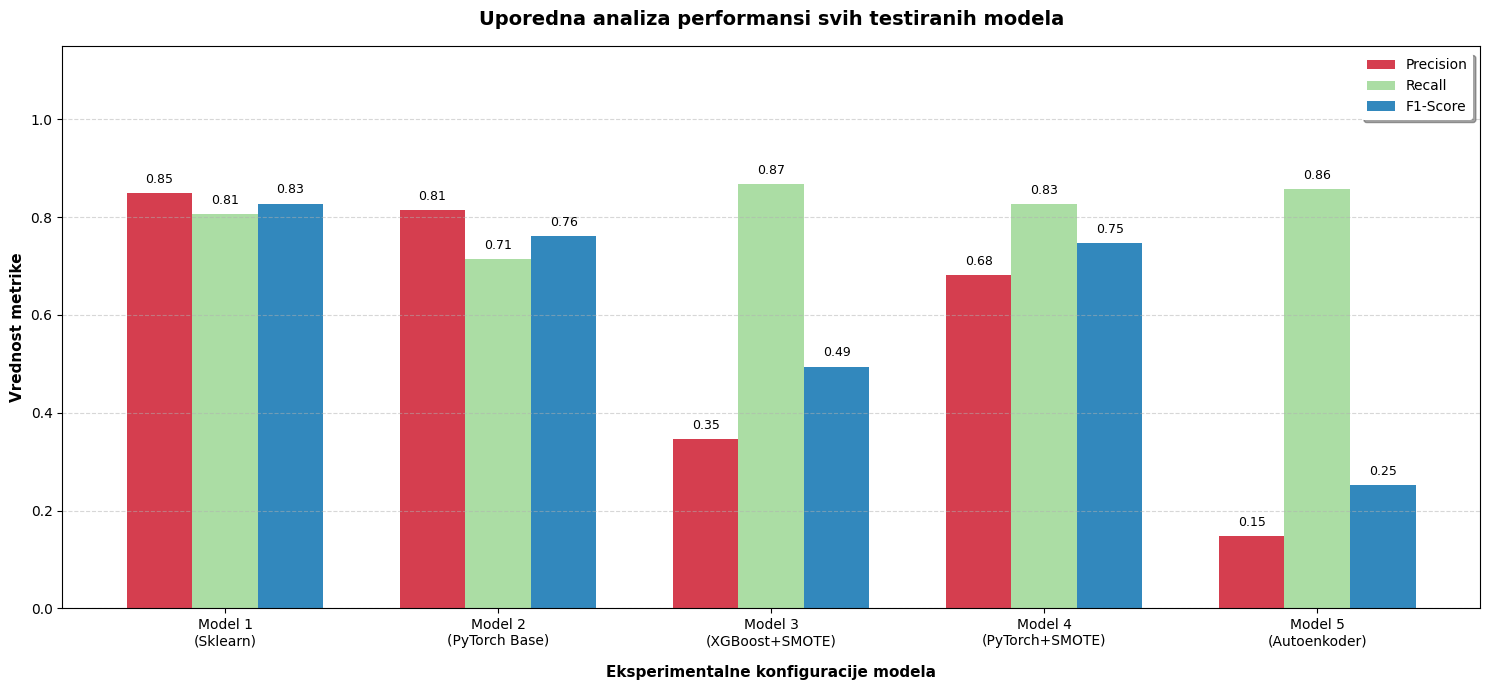


             ZBIRNA TABELA PERFORMANSI MODELA
                    Model Precision Recall F1-Score
        Model 1 (Sklearn)    0.8495 0.8061   0.8272
   Model 2 (PyTorch Base)    0.8140 0.7143   0.7609
Model 3 (XGBoost + SMOTE)    0.3455 0.8673   0.4942
Model 4 (PyTorch + SMOTE)    0.6807 0.8265   0.7465
    Model 5 (Autoenkoder)    0.1474 0.8571   0.2515


In [ ]:

# 1. Model 1 (Sklearn Baseline)
p1, r1, f1_1 = precision_score(y_test, y_pred_1, zero_division=0), recall_score(y_test, y_pred_1), f1_score(y_test, y_pred_1)

# 2. Model 2 (Osnovni PyTorch MLP)
p2, r2, f1_2 = precision_score(y_test, y_pred_2, zero_division=0), recall_score(y_test, y_pred_2), f1_score(y_test, y_pred_2)

# 3. Model 3 (XGBoost + SMOTE)
p3, r3, f1_3 = precision_score(y_test, y_pred_3_xgb, zero_division=0), recall_score(y_test, y_pred_3_xgb), f1_score(y_test, y_pred_3_xgb)

# 4. Model 4 (PyTorch MLP + SMOTE)
p4, r4, f1_4 = precision_score(y_test, y_pred_4, zero_division=0), recall_score(y_test, y_pred_4), f1_score(y_test, y_pred_4)

# 5. Model 5 (Autoenkoder)
p5, r5, f1_5 = precision_score(y_test_t.cpu().numpy(), y_pred_5, zero_division=0), recall_score(y_test_t.cpu().numpy(), y_pred_5), f1_score(y_test_t.cpu().numpy(), y_pred_5)



modeli = [
    'Model 1\n(Sklearn)',
    'Model 2\n(PyTorch Base)',
    'Model 3\n(XGBoost+SMOTE)',
    'Model 4\n(PyTorch+SMOTE)',
    'Model 5\n(Autoenkoder)'
]

precisions = [p1, p2, p3, p4, p5]
recalls = [r1, r2, r3, r4, r5]
f1_scores = [f1_1, f1_2, f1_3, f1_4, f1_5]

x = np.arange(len(modeli))
width = 0.24

plt.figure(figsize=(15, 7))
plt.bar(x - width, precisions, width, label='Precision', color='#d53e4f')
plt.bar(x, recalls, width, label='Recall', color='#abdda4')
plt.bar(x + width, f1_scores, width, label='F1-Score', color='#3288bd')

plt.xlabel('Eksperimentalne konfiguracije modela', fontsize=11, fontweight='bold', labelpad=12)
plt.ylabel('Vrednost metrike', fontsize=11, fontweight='bold')
plt.title('Uporedna analiza performansi svih testiranih modela', fontsize=14, fontweight='bold', pad=15)
plt.xticks(x, modeli, fontsize=10)
plt.ylim(0, 1.15)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='none', shadow=True)

for i in range(len(modeli)):
    plt.text(i - width, precisions[i] + 0.015, f'{precisions[i]:.2f}', ha='center', va='bottom', fontsize=9)
    plt.text(i, recalls[i] + 0.015, f'{recalls[i]:.2f}', ha='center', va='bottom', fontsize=9)
    plt.text(i + width, f1_scores[i] + 0.015, f'{f1_scores[i]:.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


df_poredjenje = pd.DataFrame({
    'Model': ['Model 1 (Sklearn)', 'Model 2 (PyTorch Base)', 'Model 3 (XGBoost + SMOTE)', 'Model 4 (PyTorch + SMOTE)', 'Model 5 (Autoenkoder)'],
    'Precision': precisions,
    'Recall': recalls,
    'F1-Score': f1_scores
})

print("\n" + "="*65)
print("             ZBIRNA TABELA PERFORMANSI MODELA")
print("="*65)
print(df_poredjenje.to_string(index=False, formatters={
    'Precision': '{:.4f}'.format,
    'Recall': '{:.4f}'.format,
    'F1-Score': '{:.4f}'.format
}))
print("="*65)

### Analiza i izbor optimalnog modela

Na osnovu rezultata vizuelizovanih na grafikonu i sumiranih u zbirnoj tabeli performansi, možemo doneti konačnu inženjersku ocenu o kvalitetu testiranih arhitektura:

#### 1. Apsolutni pobednik po balansu metrika: Model 1 (Sklearn)
* **Metrike:** Precision = 0.8495, Recall = 0.8061, F1-Score = 0.8272.
* **Zašto je najbolji:** Ovaj model ostvaruje najvišu F1-vrednost (0.8272) na celom projektu. U realnom bankarskom okruženju, on predstavlja proizvodni ideal: uspeva da presretne čak 80.61% prevara, a pritom zadržava preciznost na ekstremno visokih 84.95%. To znači da je procenat lažnih alarma minimalan (tek svaka šesta ili sedma blokirana transakcija je lažna uzbuna), čime se drastično štedi operativni resurs banke i štiti korisničko iskustvo legitimnih klijenata.

#### 2. Najbolji model u kategoriji dubokog učenja: Model 4 (PyTorch + SMOTE)
* **Metrike:** Precision = 0.6807, Recall = 0.8265, F1-Score = 0.7465.
* **Zašto je značajan:** Ukoliko je primarni cilj banke da podigne bezbednost na viši nivo i uhvati više prevara nego što to radi Model 1, Model 4 je vodeći kandidat. Zahvaljujući SMOTE tehnici balansiranja klasa, ova višeslojna neuronska mreža uspeva da podigne odziv na **82.65%** (hvata više prevara od Modela 1), uz svesno žrtvovanje dela preciznosti koja pada na 68.07%. Sa F1-score-om od 0.7465, ovo je izuzetno moćan i operativno primenjiv model.

#### 3. Analiza ekstremnih modela (Model 3 i Model 5)
* **Model 3 (XGBoost + SMOTE)** ostvaruje najviši sirovi odziv na projektu (**Recall = 0.8673**), ali uz ogroman pad preciznosti na 34.55%, što generiše preveliki broj lažnih alarma.
* **Model 5 (Autoenkoder)** ima sjajan **Recall = 0.8571**. Iako ima najniži F1-score (0.2515) zbog niske preciznosti (14.74%), njegova vrednost je naučna i konceptualna: on je jedini **nenadgledani model** na projektu. On prevare pronalazi bez ikakvog prethodnog znanja o njima, što ga čini nezamenljivim za detekciju potpuno novih, evoluiranih oblika prevara (Zero-day exploits) koje nadgledani modeli (poput Modela 1 i 4) ne bi uspeli da prepoznaju jer ih nikada ranije nisu videli u podacima za trening.

### Konačni zaključak rada:
Za stabilan, svakodnevni rad u produkciji, **Model 1 (Sklearn)** predstavlja optimalno rešenje zbog superiornog balansa. Međutim, u modernim hibridnim sistemima za detekciju prevara, idealan scenario je paralelna primena **Modela 1** (za poznate šablone) i **Modela 5 (Autoenkoder)** kao sekundarnog zaštitnog sloja zaduženog za izolaciju nepoznatih anomalija.